<a href="https://colab.research.google.com/github/ingnur5/AlgoritmosOptimizacion/blob/main/03MIAR_David%C3%81lvarezRobles_AG3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Nur Derly Carpeta Sánchez
Github: https://github.com/ingnur5/AlgoritmosOptimizacion.git

# 03MIAR - Algoritmos de optimización
## Actividad guiada 3

*David Álvarez Robles*

## Presentación

Profesor:
- Grupos A2, A3, B1, B2: David Álvarez Robles (dalvarezr@professor.universidadviu.com)

## Objetivos
- Comprender el uso de librerías de simulación del problema del agente viajero en Python
- Implementar y visualizar algoritmos de búsqueda basados en metaheurísticas
- Algoritmo de búsqueda aleatoria
- Algoritmo de búsqueda local
- Algoritmo Simulated Annealing

## Librerías y simulación del problema del agente viajero en Python
- Uso de librería tsplib95
- Visualización de datos

In [1]:
!pip install tsplib95
import tsplib95
import random
from math import e
import math
import copy
import urllib.request

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.3.0
    Uninstalling wrapt-2.3.0:
      Successfully uninstalled wrapt-2.3.0
  Attempting uninstall: tabulate
    Found existing installation: tabulate 0.9.0
    Uninstalling tabulate-0.9.0:
      Successfully uninstalled tabulate-0.9.0
  Attempting uninstall: networkx
    Found existing installation: networkx 3.6.1
    Uninstalling networkx-3.6.1:
      Successfully uninstalled networkx-3.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.42.0 requires tabulate>=0.9, but you have tabulate 0.8.10 which is incompatible.
scikit-image 0.25.2 requires networkx>=3.0, but you have networkx 2.8.8 which is incompatible.
momepy 0.11.0 

In [2]:
# Descargamos el fichero de datos (Matriz de distancias)
file = "swiss42.tsp" ;
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )

#urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file + '.gz')
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)


#http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

('swiss42.tsp', <http.client.HTTPMessage at 0x7fbb20f3f9d0>)

In [3]:
problema = tsplib95.load(file)
nodos = list(problema.get_nodes())
aristas = list(problema.get_edges())

print(problema) # Descripción estándar
print(nodos) # Nodos 0, 1, 2 ... 42
print(aristas) # Ver https://github.com/mastqe/tsplib/blob/master/swiss42.tsp

NAME: swiss42
COMMENT: 42 Staedte Schweiz (Fricker)
TYPE: TSP
DIMENSION: 42
EDGE_WEIGHT_TYPE: EXPLICIT
EDGE_WEIGHT_FORMAT: FULL_MATRIX
EDGE_WEIGHT_SECTION:
0 15 30 23 32 55 33 37 92 114 92 110 96 90 74 76 82 67 72 78 82 159 122 131 206 112 57 28 43 70 65 66 37 103 84 125 129 72 126 141 183 124
15 0 34 23 27 40 19 32 93 117 88 100 87 75 63 67 71 69 62 63 96 164 132 131 212 106 44 33 51 77 75 72 52 118 99 132 132 67 139 148 186 122
30 34 0 11 18 57 36 65 62 84 64 89 76 93 95 100 104 98 57 88 99 130 100 101 179 86 51 4 18 43 45 95 45 115 93 152 159 100 112 114 153 94
23 23 11 0 11 48 26 54 70 94 69 89 75 84 84 89 92 89 54 78 99 141 111 109 190 89 44 11 29 54 56 89 47 118 96 147 151 90 122 126 163 101
32 27 18 11 0 40 20 58 67 92 61 78 65 76 83 89 91 95 43 72 110 141 116 105 190 81 34 19 35 57 63 97 58 129 107 156 158 92 129 127 161 95
55 40 57 48 40 0 23 55 96 123 78 75 62 36 56 66 63 95 37 34 137 174 156 129 224 90 15 59 75 96 103 105 91 158 139 164 156 78 169 163 191 115
33 19 36 26 20 

23


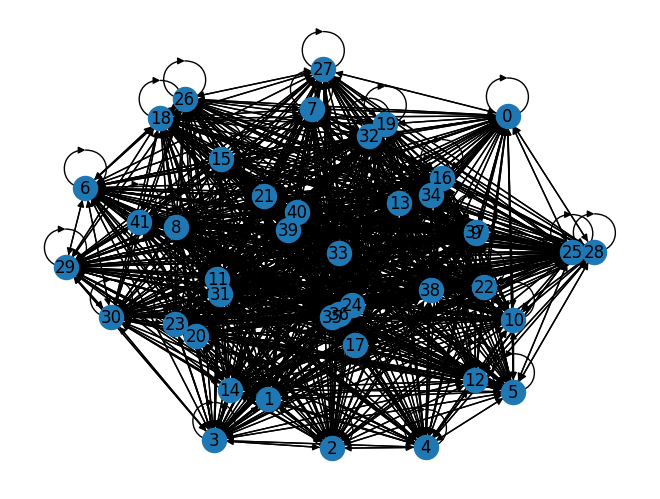

In [4]:
# Probamos algunas funciones del objeto problema, que ya nos vienen dadas

# Distancia entre nodos (ciudades)
distancia = problema.get_weight(3, 0)
print(distancia)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
#dir(problema)

import networkx as nx
import matplotlib.pyplot as plt
nx.draw(problema.get_graph(), with_labels=True, arrows=True)
plt.show()

In [5]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo TSP con solución específica")
    plt.show()

## Funciones básicas para algoritmos de búsqueda

In [6]:
# Genera una solución aleatoria con comienzo en en el nodo 0
def crear_solucion(nodos):
    # Nodo inicial = 0
    solucion = [nodos[0]]
    # Para el resto de nodos, los recorremos e incluimos aleatoriamente en la solución cada uno de ellos
    for n in nodos[1:]:
        # Debemos quitar el nodo 0 y los ya incluidos en cada iteración
        solucion = solucion + [random.choice(list(set(nodos) - set({nodos[0]}) - set(solucion)))]
    return solucion


# Devuelve la distancia entre dos nodos aprovechando la función get_weight() de tsplib95
def distancia(a,b, problema):
    return problema.get_weight(a,b)


# Devuelve la distancia total de una trayectoria/solución
def distancia_total(solucion, problema):
    distancia_total = 0
    # Para cada nodo de la solución calculamos su distancia a siguiente nodo
    for i in range(len(solucion)-1):
        distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problema)
    # Devolvemos la distancia total más la distancia del último nodo al primero para cerrar viaje
    return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problema)


solucion = crear_solucion(nodos)
print(solucion)
print(distancia_total(solucion, problema))

[0, 6, 3, 20, 25, 30, 22, 40, 4, 11, 10, 9, 36, 23, 17, 39, 28, 19, 21, 26, 16, 12, 18, 35, 27, 38, 2, 31, 29, 15, 37, 24, 32, 5, 1, 41, 13, 7, 8, 34, 33, 14]
5038


## Búsqueda aleatoria - TSP
- El algoritmo inicializa soluciones al azar y se queda con la mejor que encuentre
- Se realizan N iteraciones y nos quedamos con la mejor
- Todo es azar, sin que garanticemos solución óptima

Solución: [0, 14, 25, 17, 35, 4, 2, 28, 23, 9, 15, 19, 8, 41, 40, 39, 29, 10, 7, 22, 34, 5, 30, 32, 3, 18, 26, 31, 37, 16, 27, 11, 13, 12, 6, 24, 21, 1, 20, 36, 33, 38]
Distancia: 3834


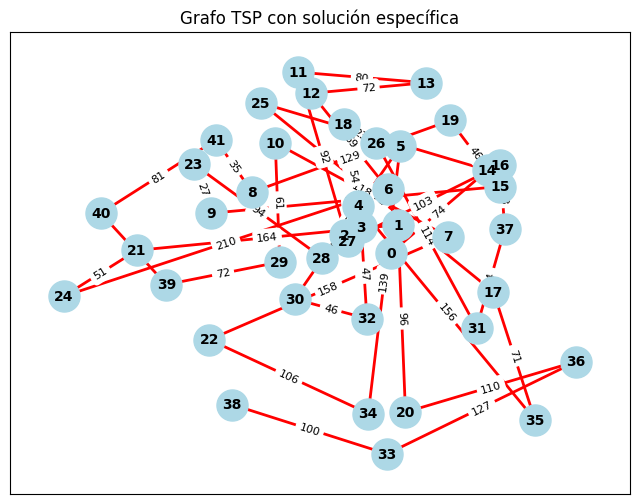

In [7]:
def busqueda_aleatoria(problema, iteraciones):
    # Obtenemos listado de nodos del problema
    nodos = list(problema.get_nodes())

    mejor_solucion = []
    mejor_distancia_total = float("inf")

    for i in range(iteraciones):
        # Generamos solución aleatoria
        solucion = crear_solucion(nodos)
        # Calculamos distancia total de la solución
        distancia = distancia_total(solucion, problema)
        if (distancia < mejor_distancia_total):
            mejor_solucion = solucion
            mejor_distancia_total = distancia

    return mejor_solucion, mejor_distancia_total

iteraciones = 5000
mejor_solucion, mejor_distancia_total = busqueda_aleatoria(problema, iteraciones)

print(f"Solución: {mejor_solucion}")
print(f"Distancia: {mejor_distancia_total}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)



## Búsqueda local - TSP
- El algoritmo se va quedando con vecinos (operadores de vecindad) para intentar converger a mejores soluciones
- Se realizan N iteraciones y nos quedamos con la mejor

In [8]:
# Función que a partir de una solución genera la vecina óptima (es decir, la mejor vecina de todas las que existen)
def genera_mejor_vecina(solucion):
    # Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones en el bucle
    # Se puede modificar para aplicar otros generadores distintos que 2-opt como inversión, barajado...
    #print(solucion)

    mejor_solucion = []
    mejor_distancia = float("inf")

    #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for i in range(1,len(solucion)-1):
        for j in range(i+1, len(solucion)):
            # Generamos nueva solución vecina (0, 1, 2, 3, i, ..., j, ..., 41) -> (0, 1, 2, 3, j, ..., i, ..., 41)
            vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

            # Se evalua la nueva solución
            distancia_vecina = distancia_total(vecina, problema)

            # Si es la mejor solución, la almacenamos
            if (distancia_vecina <= mejor_distancia):
                mejor_distancia = distancia_vecina
                mejor_solucion = vecina

    # Devolvemos mejor vecina
    return mejor_solucion


solucion = crear_solucion(nodos)
print(f"Distancia Solucion Incial: {distancia_total(solucion, problema)}")

nueva_solucion = genera_mejor_vecina(solucion)
print(f"Distancia Mejor Solucion Local: {distancia_total(nueva_solucion, problema)}")

Distancia Solucion Incial: 5071
Distancia Mejor Solucion Local: 4457


En la iteracion 35 la mejor solución encontrada es: [0, 15, 16, 14, 1, 3, 32, 20, 31, 17, 7, 10, 25, 41, 23, 39, 22, 38, 33, 34, 30, 29, 28, 27, 2, 4, 11, 12, 18, 6, 35, 36, 37, 19, 13, 5, 26, 8, 9, 40, 24, 21]
Distancia: 2036


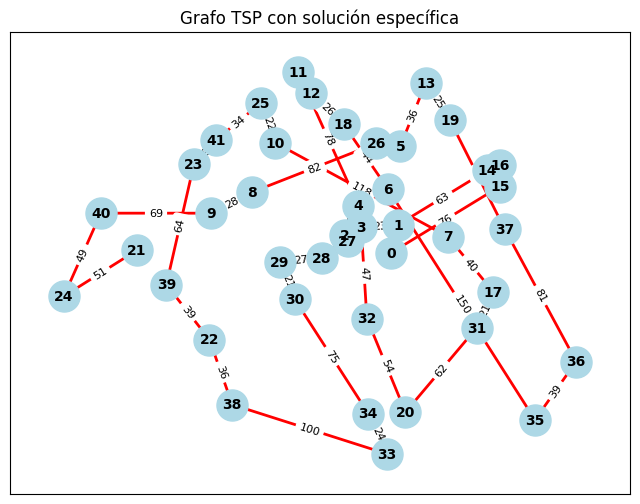

In [9]:
# En este caso, la búsqueda se ejecuta sin criterio de parada, se para cuando no es posible mejorar.
# Aquí iremos recorriendo las mejores vecinas para ir construyendo trayectoria
def busqueda_local(problema):
    mejor_solucion = []

    # Generar una solucion inicial de referencia(aleatoria)
    solucion_referencia = crear_solucion(nodos)
    mejor_distancia = distancia_total(solucion_referencia, problema)

    # Contador de iteraciones (por tener referencia)
    iteracion = 0

    while(1):
        iteracion += 1
        #print('#',iteracion)

        # Obtenemos la mejor vecina
        vecina = genera_mejor_vecina(solucion_referencia)

        # Evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
        distancia_vecina = distancia_total(vecina, problema)

        # Si mejoramos hay que seguir
        if (distancia_vecina < mejor_distancia):
            #mejor_solucion = copy.deepcopy(vecina)   # Con copia profunda. Las copias en python son por referencia
            mejor_solucion = vecina                   # Guarda la mejor solución encontrada
            mejor_distancia = distancia_vecina

        # Si no mejoramos, retornamos ya que hemos llegado a un minimo local (según nuestro operador de vecindad 2-opt)
        else:
            #print(f"En la iteracion {iteracion} la mejor solución encontrada es: {mejor_solucion}")
            #print(f"Distancia: {mejor_distancia}")
            return mejor_solucion, mejor_distancia, iteracion

        solucion_referencia = vecina


mejor_solucion, mejor_distancia, iteracion = busqueda_local(problema)
print(f"En la iteracion {iteracion} la mejor solución encontrada es: {mejor_solucion}")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)

## Recocido simulado (Simulated Annealing) - TSP
- El algoritmo se va quedando con vecinos (operadores de vecindad) para intentar converger a mejores soluciones, aunque ahora a veces puedo elegir vecinos peores
- Al principio, elijo más veces vecinos peores (diversifico) y luego elijo menos veces esos vecinos peores (intensifico)
- Se realizan N iteraciones o bajamos temperatura al máximo

### Funciones auxiliares

In [10]:
# Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
def genera_vecina_aleatorio(solucion):

  # Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample(range(1,len(solucion)) , 2))

  # Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


# Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T, d):
  if random.random() <  math.exp(-1*d / T)  :
    return True
  else:
    return False


# Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.9999

La mejor solución encontrada es: [0, 7, 17, 37, 15, 16, 14, 1, 30, 38, 22, 24, 40, 21, 39, 29, 28, 27, 2, 6, 5, 19, 13, 11, 25, 41, 23, 9, 8, 10, 12, 18, 26, 4, 3, 32, 34, 33, 20, 35, 36, 31] en 207223 iteraciones
Distancia: 1598


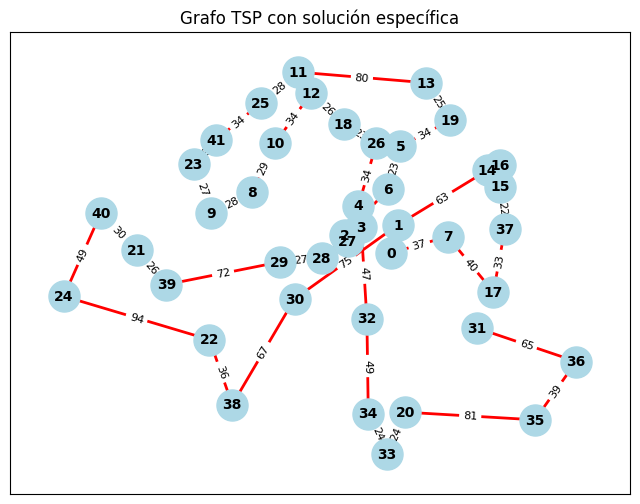

In [11]:
def recocido_simulado(problema, temperatura):
    # Generamos solución de referencia
    solucion_referencia = crear_solucion(nodos)
    distancia_referencia = distancia_total(solucion_referencia, problema)

    mejor_solucion = []
    mejor_distancia = float("inf")

    iteraciones = 0

    # Mientras la temperatura no sea 0 (aquí no hay parada por iteraciones)
    while temperatura > .0001:
        iteraciones += 1

        # Genera una solución vecina
        vecina = genera_vecina_aleatorio(solucion_referencia)

        # Calculamos distancia
        distancia_vecina = distancia_total(vecina, problema)

        # Si es la mejor solución de todas se guarda siempre
        if (distancia_vecina < mejor_distancia):
            mejor_solucion = vecina
            mejor_distancia = distancia_vecina

        # Si la nueva vecina es o
        # Si el vecino es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
        if ((distancia_vecina < distancia_referencia) or probabilidad(temperatura, abs(distancia_referencia - distancia_vecina))):
            #solucion_referencia = copy.deepcopy(vecina)
            solucion_referencia = vecina
            distancia_referencia = distancia_vecina

        # Bajamos la temperatura
        temperatura = bajar_temperatura(temperatura)

    return mejor_solucion, mejor_distancia, iteraciones

temperatura = 100000
mejor_solucion, mejor_distancia, iteraciones  = recocido_simulado(problema, temperatura)

print(f"La mejor solución encontrada es: {mejor_solucion} en {iteraciones} iteraciones")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)

## Actividades extra
- Mejora de algoritmo de búsqueda local
  - Multiarranque
  - Búsqueda en entornos variables

- Recocido simulado
  - Mejora en la selección de vecinos

## Actividades extra
- Mejora de algoritmo de búsqueda local
  - Multiarranque
  - Búsqueda en entornos variables

- Recocido simulado
  - Mejora en la selección de vecinos

---
# ACTIVIDADES EXTRA

**A partir de aquí empieza todo lo añadido para las actividades extra.** Todo lo anterior es el notebook original, sin ninguna modificación.

Se desarrollan las siguientes mejoras:
1. **Mejora del algoritmo de búsqueda local**
   - Multiarranque
   - Búsqueda en entornos variables (VNS)
2. **Recocido simulado**
   - Mejora en la selección de vecinos
---

### Multiarranque
La búsqueda local básica se queda atrapada en el primer óptimo local que encuentra, y ese óptimo depende totalmente de la solución aleatoria de partida. La idea del **multiarranque** es sencilla: repetir la búsqueda local partiendo de varias soluciones iniciales distintas y quedarnos con la mejor de todas las que se han encontrado. No evita quedar atrapado en óptimos locales, pero al explorar varias "cuencas de atracción" distintas aumenta la probabilidad de que alguna de ellas nos lleve a una solución mucho mejor.

Distancias obtenidas en cada arranque: [1755, 1796, 1708, 1613, 1781]
Mejor distancia tras 5 arranques: 1613


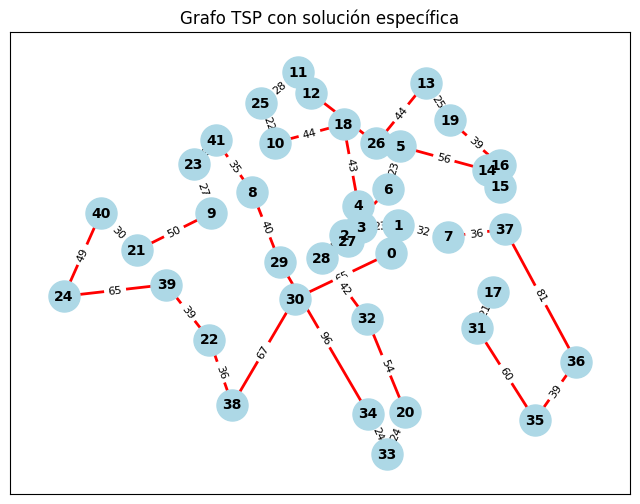

In [12]:
def busqueda_local_multiarranque(problema, n_arranques):
    # Guardamos la mejor solución encontrada en cualquiera de los arranques
    mejor_solucion_global = []
    mejor_distancia_global = float("inf")

    historico = []  # Para poder analizar el comportamiento de cada arranque

    for arranque in range(n_arranques):
        # Cada arranque es una búsqueda local completa e independiente
        # (crear_solucion() genera una solución aleatoria distinta cada vez)
        solucion, distancia, iteracion = busqueda_local(problema)
        historico.append(distancia)

        # Nos quedamos con la mejor solución de entre todos los arranques
        if distancia < mejor_distancia_global:
            mejor_solucion_global = solucion
            mejor_distancia_global = distancia

    return mejor_solucion_global, mejor_distancia_global, historico


n_arranques = 5
mejor_solucion, mejor_distancia, historico = busqueda_local_multiarranque(problema, n_arranques)

print(f"Distancias obtenidas en cada arranque: {historico}")
print(f"Mejor distancia tras {n_arranques} arranques: {mejor_distancia}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)


### Búsqueda en entornos variables (VNS)
En la búsqueda local básica usamos siempre el mismo operador de vecindad (2-opt por intercambio). El objetivo de la **búsqueda en entornos variables (VNS)** es combinar *varios* operadores de vecindad de "fuerza" distinta: cuando nos quedamos atascados en un óptimo local respecto al primer operador, en lugar de rendirnos probamos a perturbar la solución con otro operador diferente antes de reintentar la búsqueda local. Si esa perturbación consigue escapar del óptimo local y encontrar algo mejor, volvemos a intensificar con el primer operador; si no, seguimos probando operadores de perturbación cada vez algo más "agresivos".

Se usan tres entornos de perturbación, de menor a mayor grado de alteración de la solución:
- **N1 (swap):** intercambia dos ciudades de posición.
- **N2 (inversión / 2-opt real):** invierte un segmento completo del recorrido.
- **N3 (or-opt):** extrae una ciudad y la reinserta en otra posición del recorrido.

Esquema del algoritmo (VNS básico):
1. Partimos de una solución y con `k=1`.
2. Perturbamos la solución actual con el entorno `N_k` (*shaking*).
3. Aplicamos búsqueda local (2-opt) a la solución perturbada para volver a un óptimo local.
4. Si el resultado mejora la solución actual, la aceptamos y volvemos a `k=1` (intensificamos desde ahí).
5. Si no mejora, pasamos al siguiente entorno `k=k+1` (diversificamos con una perturbación distinta).
6. Repetimos hasta agotar el presupuesto de ciclos.

VNS -> Distancia: 1464 (llamadas a búsqueda local: 40)


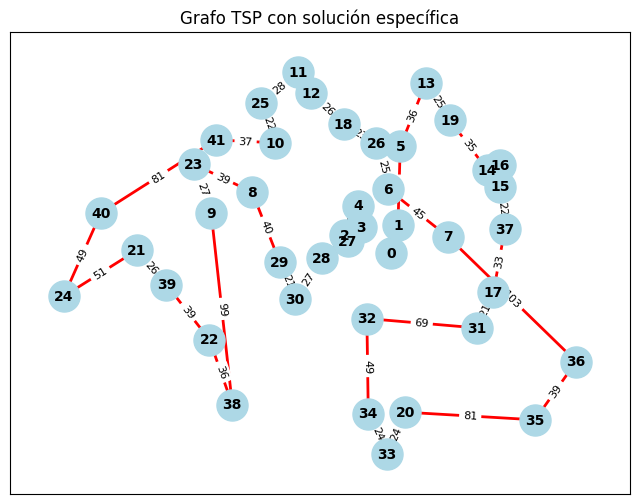

In [13]:
# --- Entornos de perturbación (shaking) ---

# N1: intercambio de dos ciudades
def perturbar_swap(solucion):
    i, j = sorted(random.sample(range(1, len(solucion)), 2))
    s = solucion[:]
    s[i], s[j] = s[j], s[i]
    return s

# N2: inversión de un segmento del recorrido (2-opt real)
def perturbar_inversion(solucion):
    i, j = sorted(random.sample(range(1, len(solucion)), 2))
    s = solucion[:]
    s[i:j+1] = reversed(s[i:j+1])
    return s

# N3: or-opt, extraemos una ciudad y la insertamos en otra posición
def perturbar_or_opt(solucion):
    L = len(solucion)
    i = random.randint(1, L - 1)
    ciudad = solucion[i]
    resto = solucion[:i] + solucion[i+1:]
    j = random.randint(1, len(resto))
    return resto[:j] + [ciudad] + resto[j:]

PERTURBACIONES = [perturbar_swap, perturbar_inversion, perturbar_or_opt]



# La búsqueda local del notebook (busqueda_local) siempre arranca de una solución
# aleatoria nueva y no admite partir de una solución dada, así que para el VNS
# necesitamos una versión de descenso 2-opt que sí reciba la solución perturbada
# como punto de partida. Reutiliza el mismo operador de vecindad (genera_mejor_vecina).
def busqueda_local_desde(problema, solucion_inicial):
    solucion_referencia = solucion_inicial
    mejor_distancia = distancia_total(solucion_referencia, problema)
    mejor_solucion = solucion_referencia

    while True:
        vecina = genera_mejor_vecina(solucion_referencia)
        distancia_vecina = distancia_total(vecina, problema)

        if distancia_vecina < mejor_distancia:
            mejor_solucion = vecina
            mejor_distancia = distancia_vecina
        else:
            return mejor_solucion, mejor_distancia

        solucion_referencia = vecina


def vns(problema, k_max=3, ciclos_maximos=8):
    solucion_actual = crear_solucion(nodos)
    distancia_actual = distancia_total(solucion_actual, problema)

    total_llamadas = 0

    for ciclo in range(ciclos_maximos):
        k = 1
        while k <= k_max:
            total_llamadas += 1

            # 1) Shaking: perturbamos la solución actual con el entorno k
            solucion_perturbada = PERTURBACIONES[k-1](solucion_actual)

            # 2) Búsqueda local (2-opt) desde la solución perturbada
            solucion_mejorada, distancia_mejorada = busqueda_local_desde(problema, solucion_perturbada)

            # 3) Si mejora, aceptamos e intensificamos volviendo al entorno N1
            if distancia_mejorada < distancia_actual:
                solucion_actual = solucion_mejorada
                distancia_actual = distancia_mejorada
                k = 1
            # 4) Si no mejora, diversificamos probando el siguiente entorno
            else:
                k += 1

    return solucion_actual, distancia_actual, total_llamadas


mejor_solucion, mejor_distancia, llamadas = vns(problema, k_max=3, ciclos_maximos=8)

print(f"VNS -> Distancia: {mejor_distancia} (llamadas a búsqueda local: {llamadas})")

plot_tsp_solution(problema.edge_weights, mejor_solucion)


### Recocido simulado: mejora en la selección de vecinos
En el recocido simulado del notebook, `genera_vecina_aleatorio()` elige **al azar y sin ningún criterio** las dos ciudades a intercambiar. Esto significa que la inmensa mayoría de los vecinos generados son irrelevantes: se intercambian dos ciudades que ya estaban razonablemente bien situadas, y el cambio no aporta nada.

La idea de mejora **no** consiste en evaluar todas las posibles vecinas y quedarnos con la mejor de todas (eso sería reutilizar `genera_mejor_vecina()`, y además tiene un coste O(n²) por iteración que anula la ventaja del recocido simulado, que necesita generar vecinos muy rápido). En su lugar, se propone **sesgar la elección aleatoria** con dos criterios de sentido común, sin evaluar nada de más:

1. **Elegir la primera ciudad con más probabilidad si está "mal situada".** Calculamos el coste de las dos aristas que llegan/salen de cada ciudad en el recorrido actual, y elegimos la ciudad con una probabilidad proporcional a ese coste (ruleta ponderada). Así es más probable "tocar" una ciudad que está generando un tramo caro del recorrido, en vez de una cualquiera.
2. **Elegir la segunda ciudad entre sus vecinas geográficamente más cercanas**, en lugar de entre las 42 ciudades del problema. Precalculamos, para cada ciudad, una lista de sus *k* ciudades más próximas (*candidate list*, técnica clásica en heurísticas de TSP). Intercambiar una ciudad mal situada por otra que está cerca geográficamente tiene muchas más papeletas de generar una mejora real que un intercambio completamente al azar.

El coste de generar cada vecina sigue siendo prácticamente O(1) (no hay ningún bucle que recorra todas las combinaciones), por lo que seguimos pudiendo hacer cientos de miles de iteraciones, pero ahora la búsqueda **intensifica** mejor porque los movimientos propuestos son mucho más prometedores que uno puramente aleatorio.

Recocido simulado (selección guiada) -> Distancia: 1442 en 207223 iteraciones


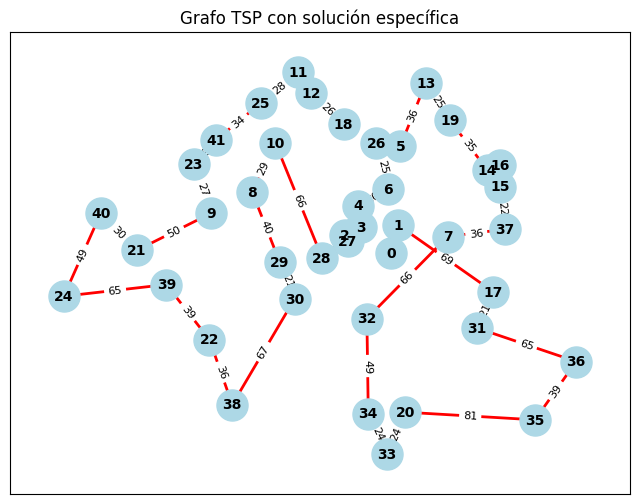

In [14]:
# Precalculamos, para cada ciudad, sus k ciudades geográficamente más cercanas
def construir_vecinos_cercanos(problema, nodos, k=6):
    vecinos_cercanos = {}
    for a in nodos:
        distancias = sorted(((b, problema.get_weight(a, b)) for b in nodos if b != a),
                             key=lambda x: x[1])
        vecinos_cercanos[a] = [b for b, _ in distancias[:k]]
    return vecinos_cercanos

VECINOS_CERCANOS = construir_vecinos_cercanos(problema, nodos, k=6)


def genera_vecina_guiada(solucion, problema):
    L = len(solucion)
    pos_de_ciudad = {ciudad: idx for idx, ciudad in enumerate(solucion)}

    # Peso de cada posición = coste de las 2 aristas que tocan esa ciudad en el recorrido actual
    # (al cuadrado para acentuar la diferencia entre aristas caras y baratas)
    posiciones = list(range(1, L))
    pesos = []
    for pos in posiciones:
        anterior = solucion[pos - 1]
        actual = solucion[pos]
        siguiente = solucion[(pos + 1) % L]
        coste = problema.get_weight(anterior, actual) + problema.get_weight(actual, siguiente)
        pesos.append(coste ** 2)

    # 1) Elegimos la primera ciudad con probabilidad proporcional a lo "cara" que es su posición
    i = random.choices(posiciones, weights=pesos, k=1)[0]
    ciudad_i = solucion[i]

    # 2) Elegimos como pareja una de sus ciudades geográficamente más cercanas
    ciudad_candidata = random.choice(VECINOS_CERCANOS[ciudad_i])
    j = pos_de_ciudad[ciudad_candidata]

    if i == j or j == 0:
        # Caso borde poco frecuente: devolvemos la solución sin modificar
        return solucion[:]

    i, j = sorted([i, j])
    return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


def recocido_simulado_mejorado(problema, temperatura):
    solucion_referencia = crear_solucion(nodos)
    distancia_referencia = distancia_total(solucion_referencia, problema)

    mejor_solucion = []
    mejor_distancia = float("inf")

    iteraciones = 0

    while temperatura > .0001:
        iteraciones += 1

        # Generamos la vecina con la selección guiada (en vez de 100% aleatoria)
        vecina = genera_vecina_guiada(solucion_referencia, problema)
        distancia_vecina = distancia_total(vecina, problema)

        if distancia_vecina < mejor_distancia:
            mejor_solucion = vecina
            mejor_distancia = distancia_vecina

        if (distancia_vecina < distancia_referencia) or probabilidad(temperatura, abs(distancia_referencia - distancia_vecina)):
            solucion_referencia = vecina
            distancia_referencia = distancia_vecina

        temperatura = bajar_temperatura(temperatura)

    return mejor_solucion, mejor_distancia, iteraciones


temperatura = 100000
mejor_solucion, mejor_distancia, iteraciones = recocido_simulado_mejorado(problema, temperatura)

print(f"Recocido simulado (selección guiada) -> Distancia: {mejor_distancia} en {iteraciones} iteraciones")

plot_tsp_solution(problema.edge_weights, mejor_solucion)


### Comparativa: selección aleatoria vs. selección guiada
Para comprobar que la mejora es real y no depende de una única ejecución con suerte, comparamos ambas versiones del recocido simulado (aleatoria original vs. guiada) lanzando cada una con las mismas semillas aleatorias.

In [15]:
resultados_aleatorio = []
resultados_guiado = []

n_semillas = 5

for semilla in range(n_semillas):
    random.seed(semilla)
    _, dist_resultado, _ = recocido_simulado(problema, temperatura)
    resultados_aleatorio.append(dist_resultado)

    random.seed(semilla)
    _, dist_resultado, _ = recocido_simulado_mejorado(problema, temperatura)
    resultados_guiado.append(dist_resultado)

print(f"Selección aleatoria -> {resultados_aleatorio}  (media: {sum(resultados_aleatorio)/n_semillas:.1f})")
print(f"Selección guiada    -> {resultados_guiado}  (media: {sum(resultados_guiado)/n_semillas:.1f})")


Selección aleatoria -> [1512, 1425, 1388, 1595, 1522]  (media: 1488.4)
Selección guiada    -> [1442, 1355, 1484, 1475, 1464]  (media: 1444.0)
